In [6]:
import sys
sys.path.append("/home/kongxiangyu/yongzhang/finnal_exp")
from utils.visualizations import plot_top_down_map , images_to_video_with_audio , combine_all_audio_data
from habitat.utils.visualizations.utils import images_to_video
from PIL import Image
import pickle , os
import numpy as np

In [198]:
path = '../dataset/pickle/v2/offline(version3)/level3/29hnd4uzFmX/1539.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)

In [183]:
print(data.keys())
print(data['obs'][0].keys())

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id', 'greedy_action', 'total_sound_point'])
dict_keys(['rgb', 'depth', 'spectrogram', 'angle'])


In [190]:
print(f"reward : {len(data['reward'])} , done {len(data['done'])} , obs {len(data['obs'])} , action {len(data['action_id'])}")

reward : 7 , done 7 , obs 8 , action 7


In [191]:
data['total_sound_point']

[[[-5.224639, -0.34820699999999993, -3.593685],
  [-5.224639, -0.34820699999999993, -3.593685],
  [-5.224639, -0.34820699999999993, -3.593685],
  [-6.224639, -0.34820699999999993, -3.593685]]]

In [4]:
data['action_id']

[3, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 3, 1, 1]

In [9]:
data['reward']

[-0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 0.99,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 0.99,
 -0.01,
 -0.01,
 -1.01,
 -0.01,
 -0.01,
 -0.01,
 -1.01,
 -1.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -1.01,
 -0.01]

### draw depth

(-0.5, 127.5, 127.5, -0.5)

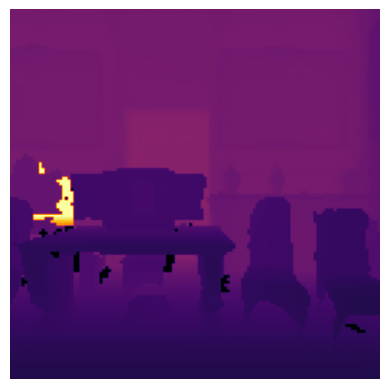

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# assume depth is your (128,128,1) array
depth_2d = np.squeeze(data['obs'][0]['depth'])  # becomes (128,128)

plt.imshow(depth_2d, cmap='inferno')
plt.axis('off')


### draw obs

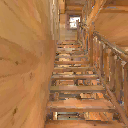

In [10]:
Image.fromarray(data['obs'][0]['rgb'])

### draw map

In [24]:
len(data['action_id'])

1

In [7]:
data['reward']

[-0.008314857482910156,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 0.23999237060546874,
 0.23999046325683593,
 0.23998950958251952,
 0.23998855590820312,
 0.2399861717224121,
 0.2399842643737793,
 0.23998188018798827,
 0.23997758865356444,
 0.23997305870056151,
 0.23996614456176757,
 0.2399566078186035,
 0.2399420642852783,
 0.23992084503173827,
 0.23988913536071776,
 0.2398323917388916,
 0.23971723556518554,
 0.23942123889923095,
 0.23815309047698974,
 -0.01,
 -0.01,
 -0.01,
 0.2931604290008545,
 -0.01,
 -0.01,
 -0.01,
 0.23960458278656005,
 0.23928611516952514,
 0.23832701683044433,
 0.23176716804504394,
 -0.01,
 -0.010789374113082886,
 -0.25620407819747926,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.01,
 -0.1940459406375885,
 -0.01,
 -0.01,
 -0.01,
 -0.22925854682922364,
 9.99]

In [10]:
data['action_id']

[0]

In [5]:
data['info'][-1]

{'distance_to_goal': 0.7806804180145264,
 'normalized_distance_to_goal': 0.1115257740020752,
 'success': 1.0,
 'spl': 0.8581198429703997,
 'softspl': 0.7449748609256349,
 'na': 53,
 'sna': 0.18867924528301888,
 'top_down_map': {'map': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'fog_of_war_mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'agent_map_coord': (163, 347),
  'agent_angle': 5.061455154682263}}

In [24]:
import pickle
from PIL import Image
path = '../dataset/pickle/v2/offline(version5)/qoiz87JEwZ2/3658.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)
Image.fromarray(data['map'][0]).save('./noise.png')

In [31]:
import os
path = '../dataset/pickle/v2/offline(version5)/level3'
scenes = [os.path.join(path , i) for i in os.listdir(path)]
files = []
for s in scenes:
    files.extend([os.path.join(s , i) for i in os.listdir(s)])

In [32]:
import pickle
from PIL import Image
# path = '../dataset/pickle/v2/offline(version4)/level3/8WUmhLawc2A/1480.pkl'
# path = '../dataset/pickle/v2/greedy(hybirdnetwork_with_RGBD_train)/2n8kARJN3HM/44081.pkl'
os.makedirs("../test_img_1" , exist_ok=True)
for index , file in enumerate(files):
    with open(file , 'rb') as f:
        data = pickle.load(f)
    Image.fromarray(data['map'][0]).save(f"../test_img_1/img_{index}.png")

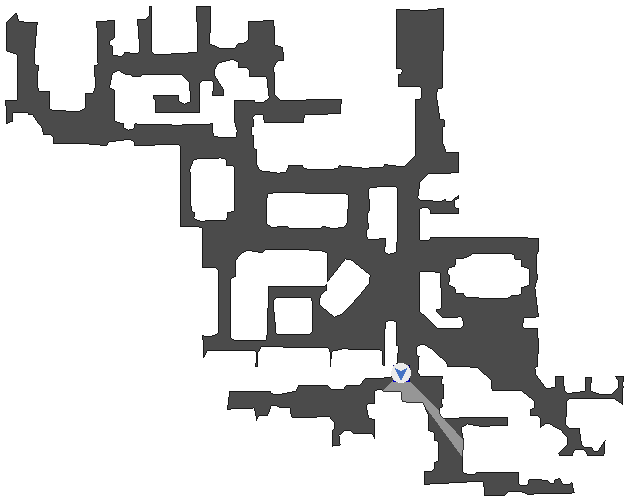

In [9]:
Image.fromarray(plot_top_down_map(data['info'][-1]))

### draw video

In [19]:
img = []
for i in data['info']:
    img.append(np.array(Image.fromarray(plot_top_down_map(i))))
images_to_video(images=img , output_dir='./' , video_name='version1_1' , fps=1)

2025-11-03 02:39:20,373 Video created: ./version1_1.mp4
100%|██████████| 18/18 [00:00<00:00, 562.65it/s]


### draw audio

In [22]:
combine_all_audio_data(data)

开始处理 14 个音频片段...
片段 0: 有声音 (最大值: 1.82e-01)
片段 1: 有声音 (最大值: 2.68e-01)
片段 2: 有声音 (最大值: 1.89e-01)
片段 3: 有声音 (最大值: 1.76e-01)
片段 4: 有声音 (最大值: 2.37e-01)
片段 5: 有声音 (最大值: 1.78e-01)
片段 6: 有声音 (最大值: 1.86e-01)
片段 7: 有声音 (最大值: 2.62e-01)
片段 8: 有声音 (最大值: 3.01e-01)
片段 9: 有声音 (最大值: 4.04e-01)
片段 10: 有声音 (最大值: 4.39e-01)
片段 11: 有声音 (最大值: 2.85e-01)
片段 12: 有声音 (最大值: 1.44e+00)
片段 13: 有声音 (最大值: 1.44e+00)
正在合并音频片段...
✅ 所有音频已合并保存至：combined_audio.wav
合并后音频形状：(224000, 2)
总时长：14.00 秒
